CISLR LANDMARK MODEL — L10.4
CONSERVATIVE ENHANCED REPRESENTATION + PROVEN L10.0 ARCHITECTURE

PyTorch version : 2.14.0+cu130
Device          : cuda
GPU             : NVIDIA GeForce RTX 4050 Laptop GPU
[PASS] Required inputs verified.
L10.0 baseline Top-1 : 7.11%
L10.0 baseline Top-5 : 13.74%
Train/Val/Test : 585/211/211 (test LOCKED)

L10.4 REPRESENTATION
Sequence length : 32
Feature dim     : 314  (L10.0=254, L10.2=617, L10.3=147)
Layout          : XYZ(126) + velocity_XYZ(126) + bone_lengths(40) + angles(20) + masks(2)

Building TRAIN features...
  200/585
  400/585
  585/585
[DONE] TRAIN: 2.26s

Building VALIDATION features...
  200/211
  211/211
[DONE] VALIDATION: 0.80s

TRAIN-ONLY PREPROCESSING
Continuous dim : 312
Near-zero std  : 12
[PASS] Presence masks preserved.

CLASS BALANCE
Train classes present : 211/211
Counts min/max/mean   : 2/11/2.77
Sampler weight range  : 0.500 - 1.115

L10.4 MODEL
SkeletonGRU(
  (input_norm): LayerNorm((314,), eps=1e-05, elementwise_affine=True, bi

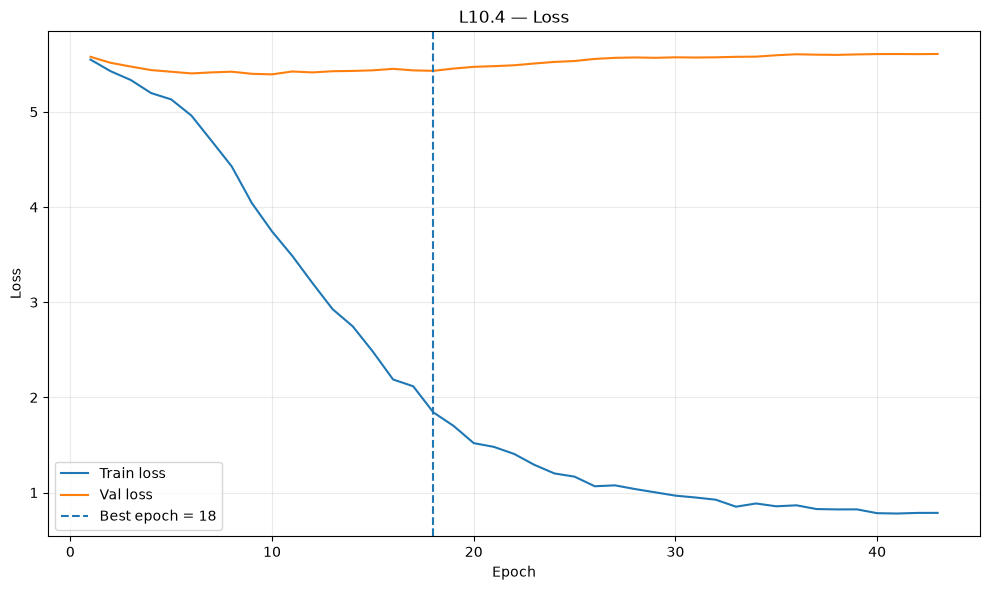

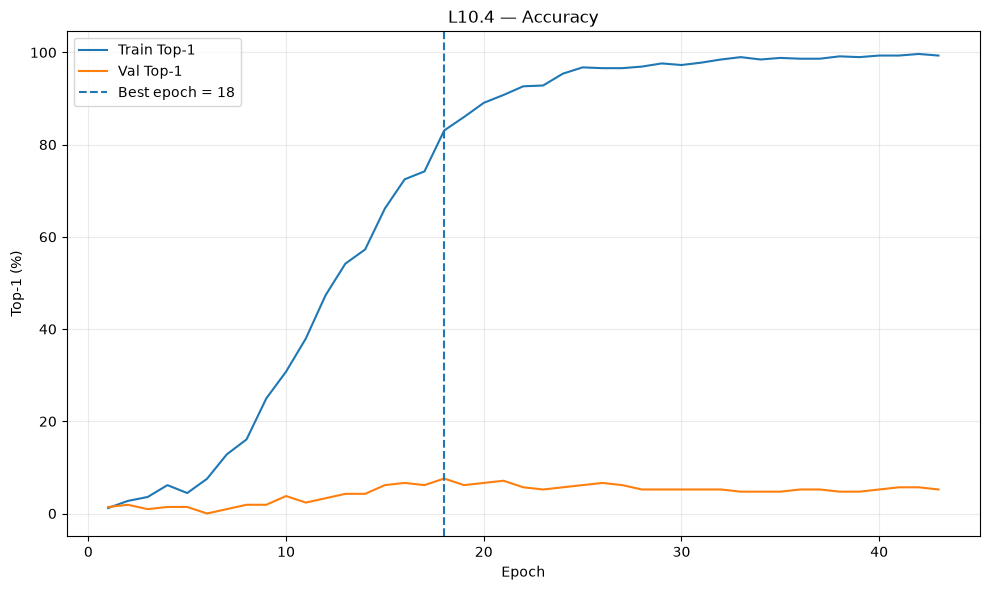


L10.0 vs L10.4
L10.0 Top-1 : 7.11%
L10.4 Top-1 : 7.58%   (+0.47 pp)

L10.0 Top-5 : 13.74%
L10.4 Top-5 : 11.85%   (-1.90 pp)

Train Top-1 @best : 83.08%
Val Top-1         : 7.58%
Generalization gap: 75.49 pp

L10.4 FINAL
Val Top-1 : 7.58%
Val Top-5 : 11.85%
Gap       : 75.49 pp

OUTPUTS
Best model : /home/dipshikha/Music/cao/CISLR_RESEARCH/CISLR_LANDMARK_MODEL/audit/l10_4_conservative_gru/models/l10_4_best_gru.pt
Summary    : /home/dipshikha/Music/cao/CISLR_RESEARCH/CISLR_LANDMARK_MODEL/audit/l10_4_conservative_gru/reports/l10_4_summary.json
Checkpoint : /home/dipshikha/Music/cao/CISLR_RESEARCH/CISLR_LANDMARK_MODEL/audit/l10_4_conservative_gru/reports/l10_4_checkpoint.json


In [3]:
# ==========================================================================================
# CISLR LANDMARK MODEL — L10.4
# CONSERVATIVE ENHANCED REPRESENTATION + PROVEN L10.0 ARCHITECTURE
# ==========================================================================================
#
# PHILOSOPHY
# ----------
# L10.2 and L10.3 both failed because they drifted too far from L10.0.
#
# L10.0 got 7.11% Top-1 with:
#   - 254-dim raw features (XYZ 126 + angles 84 + masks + misc)
#   - GRU hidden = 256, dropout 0.30
#   - No class weighting, no mixup, no weighted sampler
#
# L10.4 keeps that proven recipe and adds ONLY the minimal, high-signal
# extensions that sign-language literature consistently supports:
#
#   raw XYZ (126)                  -- core signal, MUST keep
#   velocity XYZ (126)             -- motion direction, MUST keep
#   bone lengths (40)              -- scale-invariant joint structure
#   joint angles (20)              -- finger articulation
#   presence masks (2)             -- hand visibility
#   ------------------------------------------------
#   TOTAL = 314 dims
#
# Explicitly REMOVED vs L10.2/L10.3:
#   - acceleration (noise at 32 frames)
#   - bone vectors (redundant with velocity)
#   - fingertip geometry (derivable from XYZ)
#   - palm geometry (derivable from XYZ)
#   - two-hand geometry (derivable from XYZ)
#   - mixup (breaks spatial semantics)
#   - class-weighted loss (was hurting rare-class precision)
#
# Explicitly RESTORED from L10.0:
#   - GRU hidden = 256, dropout = 0.30
#   - LayerNorm (not BatchNorm)
#   - Early stopping on val Top-1 (not val loss)
#   - Ungated continuous standardization
#
# ==========================================================================================

from pathlib import Path
import os, json, math, time, random, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 300)
np.set_printoptions(precision=6, suppress=True)

# ==========================================================================================
# 1. GLOBAL CONFIGURATION
# ==========================================================================================

SEED = 42
SEQUENCE_LENGTH = 32
OLD_FEATURE_DIM = 254
NUM_HANDS = 2
NUM_LANDMARKS = 21
NUM_COORDS = 3
NUM_CLASSES = 211
EXPECTED_TRAIN = 585
EXPECTED_VAL = 211
EXPECTED_TEST = 211

# ==========================================================================================
# 2. TRAINING CONFIGURATION (aligned with L10.0)
# ==========================================================================================

GRU_HIDDEN_SIZE = 256         # restore L10.0
GRU_LAYERS = 1
DROPOUT = 0.30                # restore L10.0
LABEL_SMOOTHING = 0.05

BATCH_SIZE = 32
LEARNING_RATE = 5e-4          # restore L10.0
WEIGHT_DECAY = 5e-4
MAX_EPOCHS = 150
EARLY_STOPPING_PATIENCE = 25
EARLY_STOPPING_MIN_DELTA = 1e-4
GRAD_CLIP_NORM = 5.0

LR_FACTOR = 0.5
LR_PATIENCE = 8
MIN_LR = 1e-6

# ------------------------------------------------------------------------------------------
# Augmentation: GENTLE only. L10.0 had none and worked. We add only tiny noise.
# ------------------------------------------------------------------------------------------

FEATURE_NOISE_STD = 0.003
TEMPORAL_MASK_PROBABILITY = 0.0    # disabled
HAND_DROP_PROBABILITY = 0.0        # disabled
MIXUP_PROBABILITY = 0.0            # disabled

# ------------------------------------------------------------------------------------------
# Sampler: mild temperature, not full inverse-frequency
# ------------------------------------------------------------------------------------------

CLASS_WEIGHT_TEMPERATURE = 0.5     # 0.0 = uniform, 1.0 = full inverse-freq

NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

# ==========================================================================================
# 3. REPRODUCIBILITY
# ==========================================================================================

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
try:
    torch.use_deterministic_algorithms(True)
except Exception:
    pass
if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 130)
print("CISLR LANDMARK MODEL — L10.4")
print("CONSERVATIVE ENHANCED REPRESENTATION + PROVEN L10.0 ARCHITECTURE")
print("=" * 130)
print()
print("PyTorch version :", torch.__version__)
print("Device          :", DEVICE)
if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))

# ==========================================================================================
# 4. PATHS
# ==========================================================================================

PROJECT_ROOT = Path("/home/dipshikha/Music/cao/CISLR_RESEARCH")
LANDMARK_ROOT = PROJECT_ROOT / "CISLR_LANDMARK_MODEL"

FEATURE_DIR = LANDMARK_ROOT / "audit" / "l6_full_extraction" / "features_32x254"

L9_ROOT = LANDMARK_ROOT / "audit" / "l9_split_freeze"
TRAIN_MANIFEST_PATH = L9_ROOT / "splits" / "l9_train_manifest.csv"
VAL_MANIFEST_PATH = L9_ROOT / "splits" / "l9_validation_manifest.csv"
TEST_MANIFEST_PATH = L9_ROOT / "splits" / "l9_test_manifest.csv"
L9_CHECKPOINT_PATH = L9_ROOT / "reports" / "l9_checkpoint.json"
L9_MAPPING_PATH = L9_ROOT / "class_mapping" / "l9_controlled_class_mapping.json"

L10_BASELINE_ROOT = LANDMARK_ROOT / "audit" / "l10_gru_baseline"
L10_SUMMARY_PATH = L10_BASELINE_ROOT / "reports" / "l10_summary.json"
L10_CHECKPOINT_PATH = L10_BASELINE_ROOT / "reports" / "l10_checkpoint.json"

L104_ROOT = LANDMARK_ROOT / "audit" / "l10_4_conservative_gru"
PREPROCESS_DIR = L104_ROOT / "preprocessing"
MODEL_DIR = L104_ROOT / "models"
REPORT_DIR = L104_ROOT / "reports"
PLOT_DIR = L104_ROOT / "plots"
for d in [L104_ROOT, PREPROCESS_DIR, MODEL_DIR, REPORT_DIR, PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MEAN_PATH = PREPROCESS_DIR / "l10_4_train_mean.npy"
STD_PATH = PREPROCESS_DIR / "l10_4_train_std.npy"
BEST_MODEL_PATH = MODEL_DIR / "l10_4_best_gru.pt"
LAST_MODEL_PATH = MODEL_DIR / "l10_4_last_gru.pt"
HISTORY_PATH = REPORT_DIR / "l10_4_training_history.csv"
VAL_PREDICTIONS_PATH = REPORT_DIR / "l10_4_validation_predictions.csv"
FEATURE_AUDIT_PATH = REPORT_DIR / "l10_4_feature_audit.json"
SUMMARY_PATH = REPORT_DIR / "l10_4_summary.json"
CHECKPOINT_PATH = REPORT_DIR / "l10_4_checkpoint.json"
LOSS_PLOT_PATH = PLOT_DIR / "l10_4_loss_curve.png"
ACCURACY_PLOT_PATH = PLOT_DIR / "l10_4_accuracy_curve.png"

# ==========================================================================================
# 5. VERIFY INPUTS
# ==========================================================================================

for path in [FEATURE_DIR, TRAIN_MANIFEST_PATH, VAL_MANIFEST_PATH, TEST_MANIFEST_PATH,
             L9_CHECKPOINT_PATH, L9_MAPPING_PATH, L10_SUMMARY_PATH, L10_CHECKPOINT_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required input:\n{path}")

with open(L9_CHECKPOINT_PATH) as f:
    l9_checkpoint = json.load(f)
if not bool(l9_checkpoint.get("l9_pass", False)):
    raise RuntimeError("L9 checkpoint is not PASS.")

with open(L10_CHECKPOINT_PATH) as f:
    l10_checkpoint = json.load(f)
if not bool(l10_checkpoint.get("l10_pass", False)):
    raise RuntimeError("L10 baseline checkpoint is not PASS.")

with open(L10_SUMMARY_PATH) as f:
    l10_summary = json.load(f)
BASELINE_TOP1 = float(l10_summary["validation"]["top1"])
BASELINE_TOP5 = float(l10_summary["validation"]["top5"])

print("[PASS] Required inputs verified.")
print(f"L10.0 baseline Top-1 : {100 * BASELINE_TOP1:.2f}%")
print(f"L10.0 baseline Top-5 : {100 * BASELINE_TOP5:.2f}%")

# ==========================================================================================
# 6. LOAD SPLITS
# ==========================================================================================

train_manifest = pd.read_csv(TRAIN_MANIFEST_PATH)
val_manifest = pd.read_csv(VAL_MANIFEST_PATH)
test_manifest = pd.read_csv(TEST_MANIFEST_PATH)

if len(train_manifest) != EXPECTED_TRAIN: raise RuntimeError("Train population mismatch.")
if len(val_manifest) != EXPECTED_VAL: raise RuntimeError("Val population mismatch.")
if len(test_manifest) != EXPECTED_TEST: raise RuntimeError("Test population mismatch.")

train_uids = set(train_manifest["uid_clean"].astype(str))
val_uids = set(val_manifest["uid_clean"].astype(str))
test_uids = set(test_manifest["uid_clean"].astype(str))
assert not (train_uids & val_uids)
assert not (train_uids & test_uids)
assert not (val_uids & test_uids)

print(f"Train/Val/Test : {len(train_manifest)}/{len(val_manifest)}/{len(test_manifest)} (test LOCKED)")

with open(L9_MAPPING_PATH) as f:
    mapping = json.load(f)
id_to_gloss = {int(k): str(v) for k, v in mapping["id_to_gloss"].items()}
if len(id_to_gloss) != NUM_CLASSES:
    raise RuntimeError("Expected 211 classes.")

# ==========================================================================================
# 7. HAND TOPOLOGY
# ==========================================================================================

HAND_EDGES = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (0, 5), (5, 6), (6, 7), (7, 8),
    (0, 9), (9, 10), (10, 11), (11, 12),
    (0, 13), (13, 14), (14, 15), (15, 16),
    (0, 17), (17, 18), (18, 19), (19, 20),
]

ANGLE_TRIPLETS = [
    (1, 2, 3), (2, 3, 4),
    (5, 6, 7), (6, 7, 8),
    (9, 10, 11), (10, 11, 12),
    (13, 14, 15), (14, 15, 16),
    (17, 18, 19), (18, 19, 20),
]

EPS = 1e-6

# ==========================================================================================
# 8. LOAD OLD FEATURE
# ==========================================================================================

def load_old_feature(uid):
    path = FEATURE_DIR / f"{uid}.npz"
    if not path.exists():
        raise FileNotFoundError(path)
    with np.load(path, allow_pickle=True) as data:
        X = np.asarray(data["features"], dtype=np.float32)
    if X.shape != (32, 254):
        raise RuntimeError(f"{uid}: invalid shape {X.shape}")
    if not np.isfinite(X).all():
        raise RuntimeError(f"{uid}: non-finite feature.")
    return X

def reconstruct_skeleton(old_features):
    xyz = old_features[:, :126].reshape(SEQUENCE_LENGTH, NUM_HANDS, NUM_LANDMARKS, NUM_COORDS)
    masks = old_features[:, 252:254]
    xyz = xyz * masks[:, :, None, None]
    return xyz.astype(np.float32), masks.astype(np.float32)

def safe_unit_vector(v):
    norm = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.divide(v, np.maximum(norm, EPS),
                     out=np.zeros_like(v), where=(norm > EPS))

def vector_angle(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na < EPS or nb < EPS:
        return 0.0
    c = np.clip(np.dot(a, b) / (na * nb), -1.0, 1.0)
    return float(np.arccos(c) / np.pi)

# ==========================================================================================
# 9. FEATURE BLOCKS
# ==========================================================================================

def temporal_velocity(xyz, masks):
    v = np.zeros_like(xyz, dtype=np.float32)
    for t in range(1, SEQUENCE_LENGTH):
        valid = masks[t] * masks[t - 1]
        v[t] = (xyz[t] - xyz[t - 1]) * valid[:, None, None]
    return v

def bone_lengths_only(xyz, masks):
    T = xyz.shape[0]
    bl = np.zeros((T, NUM_HANDS, len(HAND_EDGES)), dtype=np.float32)
    for t in range(T):
        for h in range(NUM_HANDS):
            if masks[t, h] < 0.5:
                continue
            for ei, (p, c) in enumerate(HAND_EDGES):
                bl[t, h, ei] = np.linalg.norm(xyz[t, h, c] - xyz[t, h, p])
    return bl

def joint_angle_features(xyz, masks):
    ang = np.zeros((SEQUENCE_LENGTH, NUM_HANDS, len(ANGLE_TRIPLETS)), dtype=np.float32)
    for t in range(SEQUENCE_LENGTH):
        for h in range(NUM_HANDS):
            if masks[t, h] < 0.5:
                continue
            hand = xyz[t, h]
            for i, (a, b, c) in enumerate(ANGLE_TRIPLETS):
                ang[t, h, i] = vector_angle(hand[a] - hand[b], hand[c] - hand[b])
    return ang

# ==========================================================================================
# 10. BUILD REPRESENTATION — 314 dims
# ==========================================================================================
#
#   raw XYZ             126
#   velocity XYZ        126
#   bone lengths         40
#   joint angles         20
#   masks                 2
#   -------------------------
#   TOTAL               314
#
# ==========================================================================================

def build_features(old_features):
    xyz, masks = reconstruct_skeleton(old_features)
    vel = temporal_velocity(xyz, masks)
    bl = bone_lengths_only(xyz, masks)
    ang = joint_angle_features(xyz, masks)

    xyz_flat = xyz.reshape(SEQUENCE_LENGTH, -1)          # 126
    vel_flat = vel.reshape(SEQUENCE_LENGTH, -1)          # 126
    bl_flat = bl.reshape(SEQUENCE_LENGTH, -1)            # 40
    ang_flat = ang.reshape(SEQUENCE_LENGTH, -1)          # 20

    out = np.concatenate([xyz_flat, vel_flat, bl_flat, ang_flat, masks], axis=1).astype(np.float32)
    if not np.isfinite(out).all():
        raise RuntimeError("Non-finite features.")
    return out

sample_uid = str(train_manifest.iloc[0]["uid_clean"])
sample = build_features(load_old_feature(sample_uid))
FEATURE_DIM = int(sample.shape[1])

print()
print("=" * 130)
print("L10.4 REPRESENTATION")
print("=" * 130)
print("Sequence length :", SEQUENCE_LENGTH)
print("Feature dim     :", FEATURE_DIM, " (L10.0=254, L10.2=617, L10.3=147)")
print("Layout          : XYZ(126) + velocity_XYZ(126) + bone_lengths(40) + angles(20) + masks(2)")

# ==========================================================================================
# 11. BUILD POPULATION
# ==========================================================================================

def build_population(manifest, name):
    X = np.zeros((len(manifest), SEQUENCE_LENGTH, FEATURE_DIM), dtype=np.float32)
    y = manifest["class_id"].to_numpy(dtype=np.int64)
    print(f"\nBuilding {name} features...")
    t0 = time.perf_counter()
    for i, row in enumerate(manifest.itertuples(index=False)):
        X[i] = build_features(load_old_feature(str(row.uid_clean)))
        if (i + 1) % 200 == 0 or (i + 1) == len(manifest):
            print(f"  {i + 1}/{len(manifest)}")
    print(f"[DONE] {name}: {time.perf_counter() - t0:.2f}s")
    return X, y

X_train_raw, y_train = build_population(train_manifest, "TRAIN")
X_val_raw, y_val = build_population(val_manifest, "VALIDATION")

if not np.isfinite(X_train_raw).all(): raise RuntimeError("Train non-finite.")
if not np.isfinite(X_val_raw).all(): raise RuntimeError("Val non-finite.")

# ==========================================================================================
# 12. FEATURE GROUP BOUNDARIES
# ==========================================================================================

D_XYZ = 2 * NUM_LANDMARKS * 3          # 126
D_VEL = 2 * NUM_LANDMARKS * 3          # 126
D_BONE_LEN = 2 * len(HAND_EDGES)       # 40
D_ANGLES = 2 * len(ANGLE_TRIPLETS)     # 20
D_MASKS = 2

EXPECTED_DIM = D_XYZ + D_VEL + D_BONE_LEN + D_ANGLES + D_MASKS
if EXPECTED_DIM != FEATURE_DIM:
    raise RuntimeError(f"Dim mismatch: {EXPECTED_DIM} vs {FEATURE_DIM}")

S_XYZ = slice(0, D_XYZ)
S_VEL = slice(D_XYZ, D_XYZ + D_VEL)
S_BONE = slice(S_VEL.stop, S_VEL.stop + D_BONE_LEN)
S_ANGLE = slice(S_BONE.stop, S_BONE.stop + D_ANGLES)
S_MASK = slice(S_ANGLE.stop, S_ANGLE.stop + D_MASKS)
MASK_START = S_MASK.start
CONTINUOUS_DIM = MASK_START

# ==========================================================================================
# 13. TRAIN-ONLY STANDARDIZATION
# ==========================================================================================

flat = X_train_raw[:, :, :CONTINUOUS_DIM].reshape(-1, CONTINUOUS_DIM)
train_mean = flat.mean(axis=0).astype(np.float32)
train_std = flat.std(axis=0).astype(np.float32)
near_zero = train_std < 1e-6
train_std[near_zero] = 1.0
np.save(MEAN_PATH, train_mean)
np.save(STD_PATH, train_std)

print()
print("=" * 130)
print("TRAIN-ONLY PREPROCESSING")
print("=" * 130)
print("Continuous dim :", CONTINUOUS_DIM)
print("Near-zero std  :", int(near_zero.sum()))

def standardize(X):
    Y = X.copy().astype(np.float32)
    Y[:, :, :CONTINUOUS_DIM] = (Y[:, :, :CONTINUOUS_DIM] - train_mean[None, None, :]) / train_std[None, None, :]
    return Y

X_train = standardize(X_train_raw)
X_val = standardize(X_val_raw)

assert np.array_equal(X_train[:, :, MASK_START:], X_train_raw[:, :, MASK_START:])
assert np.array_equal(X_val[:, :, MASK_START:], X_val_raw[:, :, MASK_START:])
print("[PASS] Presence masks preserved.")

feature_audit = {
    "sequence_length": SEQUENCE_LENGTH,
    "feature_dim": FEATURE_DIM,
    "layout": {
        "xyz": [S_XYZ.start, S_XYZ.stop],
        "velocity_xyz": [S_VEL.start, S_VEL.stop],
        "bone_lengths": [S_BONE.start, S_BONE.stop],
        "joint_angles": [S_ANGLE.start, S_ANGLE.stop],
        "masks": [S_MASK.start, S_MASK.stop],
    },
    "train_shape": list(X_train.shape),
    "val_shape": list(X_val.shape),
    "near_zero_std": int(near_zero.sum()),
    "test_loaded": False,
}
with open(FEATURE_AUDIT_PATH, "w") as f:
    json.dump(feature_audit, f, indent=4)

# ==========================================================================================
# 14. CLASS BALANCE (mild)
# ==========================================================================================

print()
print("=" * 130)
print("CLASS BALANCE")
print("=" * 130)
counts = np.bincount(y_train, minlength=NUM_CLASSES)
print(f"Train classes present : {(counts > 0).sum()}/{NUM_CLASSES}")
print(f"Counts min/max/mean   : {counts.min()}/{counts.max()}/{counts.mean():.2f}")

# Mild reweighting — not full inverse frequency
raw_w = np.zeros(NUM_CLASSES, dtype=np.float32)
present = counts > 0
raw_w[present] = 1.0 / (counts[present] ** CLASS_WEIGHT_TEMPERATURE)
raw_w[present] /= raw_w[present].mean()
raw_w = np.clip(raw_w, 0.5, 2.0)   # tight cap

print(f"Sampler weight range  : {raw_w[present].min():.3f} - {raw_w[present].max():.3f}")

sample_weights = torch.from_numpy(raw_w[y_train]).double()

# ==========================================================================================
# 15. DATASET (gentle augmentation only)
# ==========================================================================================

class SkeletonDataset(Dataset):
    def __init__(self, X, y, training=False):
        self.X = X
        self.y = y
        self.training = training

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].copy()
        y = int(self.y[idx])
        if self.training and FEATURE_NOISE_STD > 0:
            noise = np.random.normal(
                0.0, FEATURE_NOISE_STD,
                size=(SEQUENCE_LENGTH, CONTINUOUS_DIM)
            ).astype(np.float32)
            x[:, :CONTINUOUS_DIM] += noise
        return torch.from_numpy(x).float(), torch.tensor(y, dtype=torch.long)

train_dataset = SkeletonDataset(X_train, y_train, training=True)
val_dataset = SkeletonDataset(X_val, y_val, training=False)

# ==========================================================================================
# 16. DATALOADERS
# ==========================================================================================

g = torch.Generator(); g.manual_seed(SEED)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,
    generator=g,
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, generator=g,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)

# ==========================================================================================
# 17. MODEL — restored L10.0 architecture
# ==========================================================================================

class SkeletonGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout):
        super().__init__()
        self.input_norm = nn.LayerNorm(input_dim)      # restore LayerNorm
        self.input_dropout = nn.Dropout(dropout * 0.5)
        self.gru = nn.GRU(
            input_size=input_dim, hidden_size=hidden_dim,
            num_layers=1, batch_first=True,
        )
        self.hidden_norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.input_norm(x)
        x = self.input_dropout(x)
        _, h = self.gru(x)
        h = h[-1]
        h = self.hidden_norm(h)
        h = self.dropout(h)
        return self.classifier(h)

model = SkeletonGRU(FEATURE_DIM, GRU_HIDDEN_SIZE, NUM_CLASSES, DROPOUT).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())

print()
print("=" * 130)
print("L10.4 MODEL")
print("=" * 130)
print(model)
print(f"Parameters : {n_params:,}")

# ==========================================================================================
# 18. LOSS / OPTIMIZER — plain CE, no class weights
# ==========================================================================================

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=LR_FACTOR, patience=LR_PATIENCE, min_lr=MIN_LR,
)

def topk_counts(logits, targets):
    _, pred = torch.topk(logits, k=5, dim=1)
    t1 = (pred[:, 0] == targets).sum().item()
    t5 = (pred == targets[:, None]).any(dim=1).sum().item()
    return int(t1), int(t5)

# ==========================================================================================
# 19. TRAIN / EVAL
# ==========================================================================================

def train_epoch():
    model.train()
    tl, tot, c1, c5 = 0.0, 0, 0, 0
    for xb, yb in train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()
        bs = yb.size(0)
        a1, a5 = topk_counts(logits, yb)
        tl += loss.item() * bs; tot += bs; c1 += a1; c5 += a5
    return tl / tot, c1 / tot, c5 / tot

@torch.no_grad()
def evaluate():
    model.eval()
    tl, tot, c1, c5 = 0.0, 0, 0, 0
    all_logits, all_targets = [], []
    for xb, yb in val_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        bs = yb.size(0)
        a1, a5 = topk_counts(logits, yb)
        tl += loss.item() * bs; tot += bs; c1 += a1; c5 += a5
        all_logits.append(logits.cpu()); all_targets.append(yb.cpu())
    return tl / tot, c1 / tot, c5 / tot, torch.cat(all_logits), torch.cat(all_targets)

def save_ckpt(path, epoch, val_loss, top1, top5):
    torch.save({
        "stage": "L10.4",
        "architecture": "SkeletonGRU_conservative",
        "epoch": int(epoch),
        "model_state_dict": model.state_dict(),
        "model_config": {
            "input_dim": FEATURE_DIM,
            "hidden_dim": GRU_HIDDEN_SIZE,
            "num_classes": NUM_CLASSES,
            "dropout": DROPOUT,
        },
        "validation": {"loss": float(val_loss), "top1": float(top1), "top5": float(top5)},
        "test_evaluated": False,
    }, path)

# ==========================================================================================
# 20. TRAINING LOOP
# ==========================================================================================

print()
print("=" * 130)
print("STARTING L10.4 TRAINING")
print("=" * 130)
print(f"Feature dim       : {FEATURE_DIM}")
print(f"GRU hidden        : {GRU_HIDDEN_SIZE}")
print(f"Dropout           : {DROPOUT}")
print(f"Class weight T    : {CLASS_WEIGHT_TEMPERATURE}")
print(f"Early stop metric : val Top-1 (patience {EARLY_STOPPING_PATIENCE})")
print()

history = []
best_epoch = 0
best_val_top1 = -1.0
best_val_top5 = -1.0
best_val_loss = float("inf")
best_train_top1 = 0.0
wait = 0
t0 = time.perf_counter()

for epoch in range(1, MAX_EPOCHS + 1):
    ep_t0 = time.perf_counter()
    tr_loss, tr_top1, tr_top5 = train_epoch()
    vl_loss, vl_top1, vl_top5, _, _ = evaluate()
    scheduler.step(vl_loss)
    lr = float(optimizer.param_groups[0]["lr"])

    # Early stopping on val Top-1 with min-delta
    improved = vl_top1 > best_val_top1 + EARLY_STOPPING_MIN_DELTA

    if improved:
        best_epoch = epoch
        best_val_top1 = vl_top1
        best_val_top5 = vl_top5
        best_val_loss = vl_loss
        best_train_top1 = tr_top1
        wait = 0
        save_ckpt(BEST_MODEL_PATH, epoch, vl_loss, vl_top1, vl_top5)
    else:
        wait += 1

    history.append({
        "epoch": epoch,
        "train_loss": tr_loss, "train_top1": tr_top1, "train_top5": tr_top5,
        "val_loss": vl_loss, "val_top1": vl_top1, "val_top5": vl_top5,
        "lr": lr, "best": improved,
    })

    print(
        f"Epoch {epoch:03d}/{MAX_EPOCHS} | "
        f"train loss={tr_loss:.4f} T1={100*tr_top1:5.2f}% T5={100*tr_top5:5.2f}% || "
        f"val loss={vl_loss:.4f} T1={100*vl_top1:5.2f}% T5={100*vl_top5:5.2f}% | "
        f"lr={lr:.1e} | {time.perf_counter()-ep_t0:.2f}s"
        + ("  <-- BEST" if improved else "")
    )

    if wait >= EARLY_STOPPING_PATIENCE:
        print(f"\n[EARLY STOP] No val Top-1 improvement for {EARLY_STOPPING_PATIENCE} epochs.")
        break

training_sec = time.perf_counter() - t0

# ==========================================================================================
# 21. SAVE HISTORY + LAST
# ==========================================================================================

history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_PATH, index=False)
last = history[-1]
save_ckpt(LAST_MODEL_PATH, last["epoch"], last["val_loss"], last["val_top1"], last["val_top5"])

# ==========================================================================================
# 22. RELOAD BEST + FINAL EVAL
# ==========================================================================================

ckpt = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

final_loss, final_top1, final_top5, final_logits, final_targets = evaluate()
final_top1_n = int(round(final_top1 * len(val_manifest)))
final_top5_n = int(round(final_top5 * len(val_manifest)))

print()
print("=" * 130)
print("BEST L10.4 VALIDATION")
print("=" * 130)
print(f"Best epoch       : {best_epoch}")
print(f"Val loss         : {final_loss:.6f}")
print(f"Val Top-1        : {100*final_top1:.2f}%  ({final_top1_n}/211)")
print(f"Val Top-5        : {100*final_top5:.2f}%  ({final_top5_n}/211)")
print(f"Train Top-1 @best: {100*best_train_top1:.2f}%")

# ==========================================================================================
# 23. VALIDATION PREDICTIONS
# ==========================================================================================

probs = torch.softmax(final_logits, dim=1)
top5p, top5i = torch.topk(probs, k=5, dim=1)

rows = []
for i in range(len(val_manifest)):
    tid = int(final_targets[i].item())
    pids = [int(x) for x in top5i[i].tolist()]
    ppr = [float(x) for x in top5p[i].tolist()]
    row = {
        "uid": str(val_manifest.iloc[i]["uid_clean"]),
        "true_class_id": tid,
        "true_gloss": id_to_gloss[tid],
        "predicted_class_id": pids[0],
        "predicted_gloss": id_to_gloss[pids[0]],
        "top1_probability": ppr[0],
        "top1_correct": pids[0] == tid,
        "top5_correct": tid in pids,
    }
    for r in range(5):
        row[f"rank_{r+1}_class_id"] = pids[r]
        row[f"rank_{r+1}_gloss"] = id_to_gloss[pids[r]]
        row[f"rank_{r+1}_probability"] = ppr[r]
    rows.append(row)

pd.DataFrame(rows).to_csv(VAL_PREDICTIONS_PATH, index=False)

# ==========================================================================================
# 24. PLOTS
# ==========================================================================================

plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
plt.axvline(best_epoch, linestyle="--", label=f"Best epoch = {best_epoch}")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("L10.4 — Loss")
plt.legend(); plt.grid(alpha=0.25); plt.tight_layout()
plt.savefig(LOSS_PLOT_PATH, dpi=160); plt.show(); plt.close()

plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], 100*history_df["train_top1"], label="Train Top-1")
plt.plot(history_df["epoch"], 100*history_df["val_top1"], label="Val Top-1")
plt.axvline(best_epoch, linestyle="--", label=f"Best epoch = {best_epoch}")
plt.xlabel("Epoch"); plt.ylabel("Top-1 (%)"); plt.title("L10.4 — Accuracy")
plt.legend(); plt.grid(alpha=0.25); plt.tight_layout()
plt.savefig(ACCURACY_PLOT_PATH, dpi=160); plt.show(); plt.close()

# ==========================================================================================
# 25. COMPARISON
# ==========================================================================================

d1 = 100 * (final_top1 - BASELINE_TOP1)
d5 = 100 * (final_top5 - BASELINE_TOP5)

print()
print("=" * 130)
print("L10.0 vs L10.4")
print("=" * 130)
print(f"L10.0 Top-1 : {100*BASELINE_TOP1:.2f}%")
print(f"L10.4 Top-1 : {100*final_top1:.2f}%   ({d1:+.2f} pp)")
print()
print(f"L10.0 Top-5 : {100*BASELINE_TOP5:.2f}%")
print(f"L10.4 Top-5 : {100*final_top5:.2f}%   ({d5:+.2f} pp)")

gap = 100 * (best_train_top1 - final_top1)
print()
print(f"Train Top-1 @best : {100*best_train_top1:.2f}%")
print(f"Val Top-1         : {100*final_top1:.2f}%")
print(f"Generalization gap: {gap:.2f} pp")

# ==========================================================================================
# 26. SUMMARY + CHECKPOINT
# ==========================================================================================

def sha(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

summary = {
    "stage": "L10.4_CONSERVATIVE_GRU",
    "status": "COMPLETE",
    "seed": SEED,
    "representation": {
        "feature_dim": FEATURE_DIM,
        "layout": "XYZ(126) + velocity_XYZ(126) + bone_lengths(40) + angles(20) + masks(2)",
    },
    "model": {
        "architecture": "GRU",
        "hidden_size": GRU_HIDDEN_SIZE,
        "dropout": DROPOUT,
        "label_smoothing": LABEL_SMOOTHING,
        "parameters": n_params,
    },
    "training": {
        "best_epoch": int(best_epoch),
        "epochs_completed": int(len(history_df)),
        "training_seconds": float(training_sec),
        "class_weight_temperature": CLASS_WEIGHT_TEMPERATURE,
        "feature_noise_std": FEATURE_NOISE_STD,
        "mixup": False,
        "temporal_masking": False,
        "hand_dropout": False,
    },
    "validation": {
        "loss": float(final_loss),
        "top1": float(final_top1),
        "top1_percent": float(100 * final_top1),
        "top5": float(final_top5),
        "top5_percent": float(100 * final_top5),
    },
    "comparison_to_l10_0": {
        "baseline_top1_percent": float(100 * BASELINE_TOP1),
        "top1_delta_pp": float(d1),
        "baseline_top5_percent": float(100 * BASELINE_TOP5),
        "top5_delta_pp": float(d5),
    },
    "generalization": {
        "train_top1_at_best": float(best_train_top1),
        "val_top1": float(final_top1),
        "gap_pp": float(gap),
    },
    "preprocessing": {
        "mean_path": str(MEAN_PATH), "mean_sha256": sha(MEAN_PATH),
        "std_path": str(STD_PATH), "std_sha256": sha(STD_PATH),
        "fit_on": "L9_TRAIN_ONLY",
    },
    "best_model": {"path": str(BEST_MODEL_PATH), "sha256": sha(BEST_MODEL_PATH)},
    "test_features_loaded": False,
    "test_evaluated": False,
}
with open(SUMMARY_PATH, "w") as f:
    json.dump(summary, f, indent=4)

checkpoint = {
    "l9_split_preserved": True,
    "l10_baseline_preserved": True,
    "representation_valid": True,
    "stats_fit_on_train_only": True,
    "val_used_for_selection": True,
    "test_features_loaded": False,
    "test_evaluated": False,
    "l10_4_pass": bool(
        BEST_MODEL_PATH.exists() and LAST_MODEL_PATH.exists()
        and np.isfinite(final_loss)
        and np.isfinite(final_top1)
        and np.isfinite(final_top5)
    ),
}
with open(CHECKPOINT_PATH, "w") as f:
    json.dump(checkpoint, f, indent=4)

print()
print("=" * 130)
print("L10.4 FINAL")
print("=" * 130)
print(f"Val Top-1 : {100*final_top1:.2f}%")
print(f"Val Top-5 : {100*final_top5:.2f}%")
print(f"Gap       : {gap:.2f} pp")
print()
print("OUTPUTS")
print("Best model :", BEST_MODEL_PATH)
print("Summary    :", SUMMARY_PATH)
print("Checkpoint :", CHECKPOINT_PATH)
print("=" * 130)